In [1]:
from joblib import load, dump
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from util import utils as ut
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier

import os

try:
    os.chdir("./aulas_teoricas")
except FileNotFoundError:
    pass

In [2]:
lista_files = ['./data/'+i for i in os.listdir('./data') if i.endswith('.csv')]
lista_files

['./data/04_aula_df_gera.csv',
 './data/06_aula_df_biomarc.csv',
 './data/07_aula_07_df_projeto_estruturada.csv']

In [3]:
# df = pd.read_csv(lista_files[1])
# df.head()

# 07_aula_07_df_projeto

In [4]:
# dump(df, "./data/07_aula_07_df_projeto")

df_projeto = load("./data/07_aula_07_df_projeto")
df_projeto.head()

,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,...,IgA_2,IgM,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe
0,0.119362,True,True,0.471228,0.398837,0.233216,0.329756,0.417118,True,True,...,Alto,Alto,247.894093,396.067195,0.967908,93,230,42,Normal,leucemia
1,0.112420,True,True,0.292042,0.370941,0.253135,0.340733,0.350616,True,True,...,Alto,Alto,213.416161,361.036864,0.972741,135,351,64,Normal,leucemia
2,0.175636,True,True,0.372872,0.257518,0.451758,0.487803,0.399385,True,True,...,Alto,Alto,296.635039,244.867766,0.971384,69,238,44,Normal,leucemia
3,0.078518,True,True,0.469943,0.495637,0.351360,0.332752,0.487439,True,True,...,Alto,Alto,564.401375,530.296010,0.962450,90,262,41,Normal,leucemia
4,0.061083,True,True,0.349343,0.381742,0.220939,0.479723,0.453555,True,True,...,Alto,Alto,238.791009,152.442218,0.955740,76,209,46,Normal,leucemia


In [5]:
df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 38 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   CD34      1000 non-null   float64
 1   TdT       1000 non-null   bool   
 2   MPO       1000 non-null   bool   
 3   CD19_1    1000 non-null   float64
 4   CD20_1    1000 non-null   float64
 5   CD22      1000 non-null   float64
 6   CD3_1     956 non-null    float64
 7   CD7       1000 non-null   float64
 8   BCR-ABL   1000 non-null   bool   
 9   PML-RARA  1000 non-null   bool   
 10  NMP22     1000 non-null   int64  
 11  BTA       965 non-null    object 
 12  hTERT     954 non-null    object 
 13  uCyt+     971 non-null    object 
 14  FGFR3     930 non-null    object 
 15  TP53      1000 non-null   float64
 16  PPD       916 non-null    float64
 17  IFN-γ     1000 non-null   float64
 18  IL-2      1000 non-null   object 
 19  TNF-α     1000 non-null   object 
 20  Th1       1000 non-null   int64

# Verificando as variáveis

## Removendo constantes

In [6]:
df_projeto.select_dtypes(include='object').value_counts().to_frame()

0
BTA   hTERT uCyt+ FGFR3  IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe               
False False False Normal Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer            237
                         Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG               229
                         Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia  196
                                     Alto  Baixo Alto  Alto  Normal   leucemia          174

In [7]:
df_projeto.drop(['FGFR3','BTA','hTERT','uCyt+'], axis=1, inplace=True)
df_projeto.select_dtypes(include='object').value_counts().to_frame()

0
IL-2  TNF-α IgG_1 IgA_1 IgA_2 IgM   FOXP3    classe               
Baixo Baixo Alto  Baixo Alto  Alto  Normal   cancer            269
Alto  Alto  Alto  Alto  Alto  Alto  Normal   BCG               264
Baixo Baixo Baixo Baixo Baixo Baixo Alterado imunodeficiencia  240
            Alto  Baixo Alto  Alto  Normal   leucemia          227

## Valores faltantes

### CD3_1

In [8]:
coluna = 'CD3_1'
df_projeto[coluna].describe()

count    956.000000
mean       0.301079
std        0.121323
min        0.100240
25%        0.187807
50%        0.310391
75%        0.416495
max        0.498341
Name: CD3_1, dtype: float64

In [9]:
q1 = df_projeto[coluna].describe()['25%']
q2 = df_projeto[coluna].describe()['75%']
std = df_projeto[coluna].describe()['std'] / 2
amostra = df_projeto[coluna].isna().sum() // 2

selected = (df_projeto[coluna] >= q1) & (q2 > df_projeto[coluna])
super = [i + std for i in df_projeto[selected][coluna].sample(amostra)]
infer = [j - std for j in df_projeto[selected][coluna].sample(amostra)]

index = df_projeto[df_projeto[coluna].isna()].index

df_projeto.loc[index, coluna] = super + infer
df_projeto[coluna].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000 entries, 0 to 999
Series name: CD3_1
Non-Null Count  Dtype  
--------------  -----  
1000 non-null   float64
dtypes: float64(1)
memory usage: 7.9 KB


In [10]:
df_projeto[coluna].describe()

count    1000.000000
mean        0.301436
std         0.120137
min         0.100240
25%         0.190729
50%         0.310391
75%         0.412541
max         0.498341
Name: CD3_1, dtype: float64

### PPD

In [11]:
coluna = 'PPD'
df_projeto[coluna].describe()

count    916.000000
mean      41.022804
std       69.500416
min        1.011322
25%        4.132063
50%        7.575804
75%       27.341549
max      248.759379
Name: PPD, dtype: float64

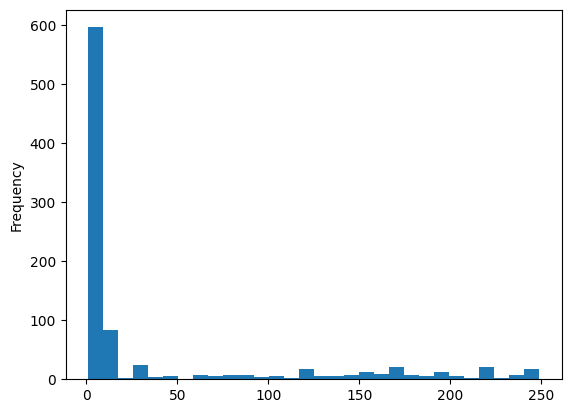

In [12]:
# Dados sem tratamento
df_projeto[coluna].plot(kind='hist', bins=30)
plt.show()

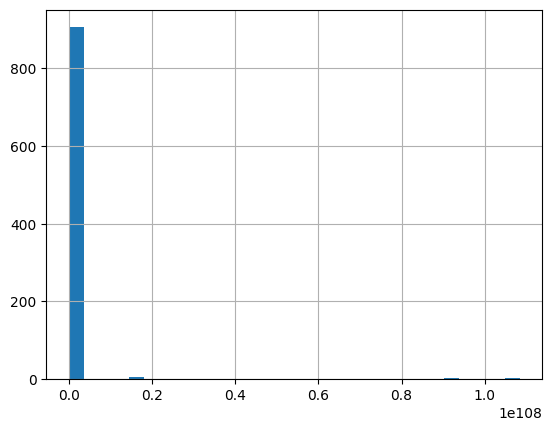

In [13]:
# Dados com transformação exponencial
np.exp(df_projeto[coluna]).hist(bins=30)
plt.show()

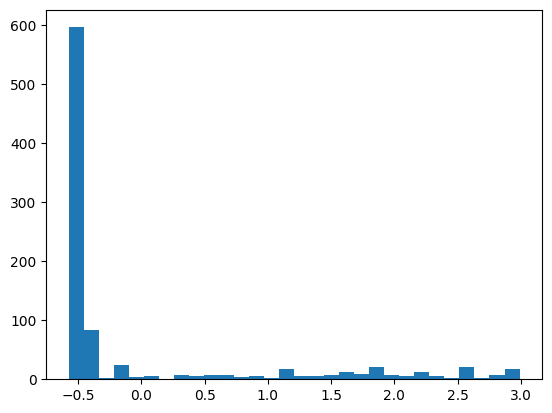

In [14]:
# Dados com padronização
scaler = StandardScaler()
dados_padronizados = scaler.fit_transform(df_projeto[coluna].to_frame())
plt.hist(dados_padronizados, bins=30)
plt.show()

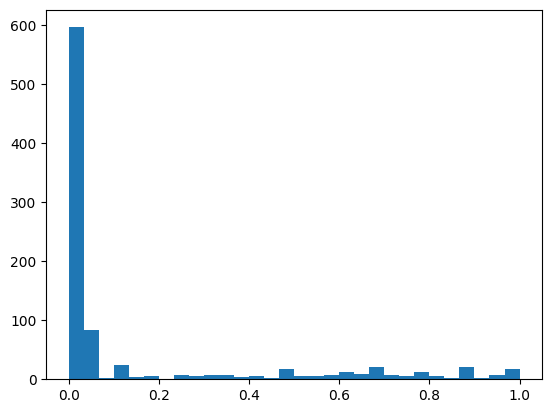

In [15]:
# Dados com normalização
scaler = MinMaxScaler()
dados_padronizados = scaler.fit_transform(df_projeto[coluna].to_frame())
plt.hist(dados_padronizados, bins=30)
plt.show()

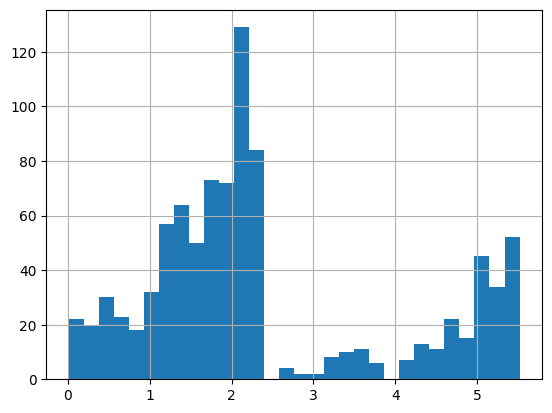

In [16]:
# Dados com transformação logarítmica
np.log(df_projeto[coluna]).hist(bins=30)
plt.show()

In [17]:
df_projeto[coluna].describe()

count    916.000000
mean      41.022804
std       69.500416
min        1.011322
25%        4.132063
50%        7.575804
75%       27.341549
max      248.759379
Name: PPD, dtype: float64

In [18]:
df_projeto[coluna+'_log'] = np.log(df_projeto[coluna])
df_projeto.drop(coluna, axis=1, inplace=True)

df_projeto[coluna+'_log'].fillna(df_projeto[coluna+'_log'].mean(), inplace=True)

df_projeto[coluna+'_log'].describe()

count    1000.000000
mean        2.400111
std         1.478031
min         0.011259
25%         1.470395
50%         2.099889
75%         2.400111
max         5.516486
Name: PPD_log, dtype: float64

In [19]:
df_projeto.isna().sum().sum()

0

## Valores correlacionados

In [20]:
corr = df_projeto.select_dtypes(include='number').corr()
corr.style.background_gradient(cmap='coolwarm')

,CD34,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,0.675640,0.676542,0.638511,0.659680,0.701262,0.017514,-0.029565,-0.447072,-0.404503,0.335673,0.364862,0.364315,-0.365406,-0.341087,-0.291381,-0.293282,0.390118,-0.386217,0.286640,0.338805,-0.425739
CD19_1,0.675640,1.000000,0.704822,0.693752,0.751028,0.739923,0.019575,-0.073669,-0.463674,-0.459872,0.392757,0.332644,0.396640,-0.438788,-0.393870,-0.319914,-0.284299,0.411213,-0.428957,0.336368,0.353058,-0.475579
CD20_1,0.676542,0.704822,1.000000,0.723823,0.742292,0.744944,0.085606,0.037263,-0.485246,-0.446376,0.333591,0.342020,0.412925,-0.390023,-0.372545,-0.320776,-0.309772,0.421285,-0.376961,0.389664,0.348129,-0.521164
CD22,0.638511,0.693752,0.723823,1.000000,0.725489,0.743305,0.024136,0.031735,-0.478440,-0.469373,0.306929,0.385390,0.424806,-0.431149,-0.360406,-0.353081,-0.350336,0.436630,-0.423453,0.392429,0.368528,-0.456771
CD3_1,0.659680,0.751028,0.742292,0.725489,1.000000,0.715480,0.078377,0.037442,-0.441387,-0.395715,0.379379,0.337211,0.449141,-0.483626,-0.405100,-0.395076,-0.366300,0.451529,-0.457999,0.410264,0.390385,-0.460790
CD7,0.701262,0.739923,0.744944,0.743305,0.715480,1.000000,0.047687,-0.070678,-0.451499,-0.405081,0.397909,0.402259,0.437757,-0.459839,-0.454433,-0.345152,-0.342859,0.475050,-0.462925,0.417713,0.393717,-0.426265
NMP22,0.017514,0.019575,0.085606,0.024136,0.078377,0.047687,1.000000,-0.128236,-0.017829,0.040820,0.020838,-0.032188,0.017963,-0.030100,0.082062,-0.046911,0.031149,0.021818,-0.011133,-0.009637,-0.029106,0.002296
TP53,-0.029565,-0.073669,0.037263,0.031735,0.037442,-0.070678,-0.128236,1.000000,0.015478,0.043840,0.005653,0.064368,0.042058,-0.052677,-0.046841,-0.008685,-0.079854,0.036826,-0.051395,0.126733,-0.022775,-0.043580
IFN-γ,-0.447072,-0.463674,-0.485246,-0.478440,-0.441387,-0.451499,-0.017829,0.015478,1.000000,0.768988,0.228079,0.171502,0.188294,-0.230803,-0.220709,-0.216476,-0.172332,0.230160,-0.223720,0.142447,0.208692,0.739156
Th1,-0.404503,-0.459872,-0.446376,-0.469373,-0.395715,-0.405081,0.040820,0.043840,0.768988,1.000000,0.225576,0.238339,0.231082,-0.255171,-0.271027,-0.215567,-0.164699,0.236626,-0.227121,0.170310,0.249999,0.760035


In [21]:
corr = df_projeto.corr()
limite = 0.8
corr[corr > limite].style.background_gradient(cmap='coolwarm')

/tmp/ipykernel_1087/2795813377.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_projeto.corr()


,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
TdT,nan,1.000000,1.000000,0.836412,0.857950,0.844706,0.848808,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MPO,nan,1.000000,1.000000,0.836412,0.857950,0.844706,0.848808,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD19_1,nan,0.836412,0.836412,1.000000,nan,nan,nan,nan,0.836412,0.836412,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD20_1,nan,0.857950,0.857950,nan,1.000000,nan,nan,nan,0.857950,0.857950,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD22,nan,0.844706,0.844706,nan,nan,1.000000,nan,nan,0.844706,0.844706,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD3_1,nan,0.848808,0.848808,nan,nan,nan,1.000000,nan,0.848808,0.848808,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD7,nan,0.862957,0.862957,nan,nan,nan,nan,1.000000,0.862957,0.862957,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BCR-ABL,nan,1.000000,1.000000,0.836412,0.857950,0.844706,0.848808,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
PML-RARA,nan,1.000000,1.000000,0.836412,0.857950,0.844706,0.848808,0.862957,1.000000,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [22]:
corr = df_projeto.corr()
corr[corr < -limite].style.background_gradient(cmap='coolwarm')

/tmp/ipykernel_1087/3842955009.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_projeto.corr()
/usr/local/lib/python3.10/site-packages/pandas/io/formats/style.py:3931: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/usr/local/lib/python3.10/site-packages/pandas/io/formats/style.py:3932: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,CD34,TdT,MPO,CD19_1,CD20_1,CD22,CD3_1,CD7,BCR-ABL,PML-RARA,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
TdT,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
MPO,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD19_1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD20_1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD22,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD3_1,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD7,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
BCR-ABL,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
PML-RARA,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan


In [23]:
classes = df_projeto['classe'].unique()
c = 0
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'leucemia'

,CD34,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,0.047672,-0.043078,-0.108879,-0.008670,0.105001,-0.048216,-0.011662,-0.130017,0.150921,0.077242,0.131217,-0.109192,0.075321,0.077017,0.083464,0.035228,-0.074258,0.016346,-0.200217,0.061030,0.158240
CD19_1,0.047672,1.000000,-0.014358,-0.079371,0.158253,0.128875,0.032222,-0.143915,0.072221,-0.122491,0.371108,-0.070865,0.020611,-0.182574,-0.148062,0.045896,0.144393,-0.111698,-0.108694,-0.154588,0.027256,-0.047011
CD20_1,-0.043078,-0.014358,1.000000,0.072677,0.143610,0.041316,0.120877,0.081989,-0.050788,0.183617,0.041291,-0.036886,0.186498,0.102849,-0.037694,0.001417,0.180368,0.135330,0.133826,-0.036615,0.037248,-0.166822
CD22,-0.108879,-0.079371,0.072677,1.000000,0.082191,-0.027753,-0.111528,0.109506,-0.153637,-0.118784,-0.215971,0.084052,0.094664,-0.035047,0.116565,-0.143233,0.074713,0.126407,0.045360,0.072582,0.046300,0.000747
CD3_1,-0.008670,0.158253,0.143610,0.082191,1.000000,0.078461,0.093752,0.106688,-0.224397,0.124786,0.111175,-0.123776,0.031265,-0.018987,-0.053987,0.036545,0.029961,0.036199,0.012663,-0.148936,-0.129408,-0.139373
CD7,0.105001,0.128875,0.041316,-0.027753,0.078461,1.000000,0.042724,-0.178642,-0.020249,0.191664,0.062459,0.090609,0.039553,-0.016377,-0.262260,0.140482,0.003834,-0.129198,-0.074074,-0.054067,0.080622,0.170066
NMP22,-0.048216,0.032222,0.120877,-0.111528,0.093752,0.042724,1.000000,-0.121451,-0.012797,-0.005209,0.086836,-0.031824,-0.028079,0.070805,0.133071,-0.117748,0.098306,0.020707,0.053396,-0.086667,-0.185592,0.068581
TP53,-0.011662,-0.143915,0.081989,0.109506,0.106688,-0.178642,-0.121451,1.000000,-0.156875,0.090906,-0.172863,0.157454,-0.024106,-0.115094,0.013210,-0.011108,-0.057496,-0.141832,-0.007025,0.288417,-0.091505,-0.166840
IFN-γ,-0.130017,0.072221,-0.050788,-0.153637,-0.224397,-0.020249,-0.012797,-0.156875,1.000000,-0.126690,-0.026483,0.107715,0.095257,-0.133663,0.040647,-0.091170,0.026188,0.021931,-0.082169,-0.000390,-0.030669,-0.285954
Th1,0.150921,-0.122491,0.183617,-0.118784,0.124786,0.191664,-0.005209,0.090906,-0.126690,1.000000,-0.152534,0.073426,0.012239,-0.032564,-0.189021,0.011998,0.131612,-0.096467,0.238759,0.069916,-0.022687,0.056490


In [24]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'cancer'

,CD34,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,0.048740,0.025285,-0.084188,-0.073891,0.088764,-0.021788,-0.122664,0.035611,0.125940,0.149043,0.141859,0.039102,0.119474,0.006022,-0.009959,0.083578,-0.030831,-0.079364,-0.219301,0.017369,-0.005614
CD19_1,0.048740,1.000000,-0.067574,-0.013335,0.197930,0.136151,-0.010260,-0.177768,0.006924,-0.046167,0.304029,0.030261,-0.078645,-0.166887,-0.134953,0.089441,0.184134,-0.050147,-0.234417,-0.176623,-0.006341,-0.113274
CD20_1,0.025285,-0.067574,1.000000,-0.050244,0.116571,0.020897,0.144327,0.132265,0.016389,0.135753,0.006806,-0.057071,0.033140,0.037968,0.043114,0.011885,0.037962,0.042424,0.189006,0.080895,-0.004119,-0.355033
CD22,-0.084188,-0.013335,-0.050244,1.000000,0.014932,0.169952,0.008716,0.079996,-0.047693,-0.229483,-0.130829,0.130630,0.071398,-0.091643,0.100808,-0.007321,-0.067586,0.059600,-0.083569,-0.006567,-0.020754,0.143062
CD3_1,-0.073891,0.197930,0.116571,0.014932,1.000000,-0.104427,0.059511,0.125894,-0.120210,-0.009851,0.060076,-0.107539,-0.055033,-0.044195,0.044106,0.015907,-0.025827,0.020314,0.016601,-0.097216,-0.037584,-0.312581
CD7,0.088764,0.136151,0.020897,0.169952,-0.104427,1.000000,-0.003181,-0.179922,0.084231,0.079378,0.080216,0.166694,-0.048679,-0.056367,-0.276591,0.118432,0.100519,-0.022278,-0.152242,-0.027632,0.050338,0.068489
NMP22,-0.021788,-0.010260,0.144327,0.008716,0.059511,-0.003181,1.000000,-0.109352,-0.027280,-0.071191,-0.006658,-0.003775,-0.184773,-0.014915,0.276175,-0.079239,0.075614,-0.037593,-0.060793,-0.152325,-0.148093,-0.090767
TP53,-0.122664,-0.177768,0.132265,0.079996,0.125894,-0.179922,-0.109352,1.000000,-0.031944,0.141083,-0.069160,0.089061,0.037599,-0.054298,-0.006368,-0.034115,-0.089637,-0.122213,0.137627,0.155922,-0.065171,-0.129505
IFN-γ,0.035611,0.006924,0.016389,-0.047693,-0.120210,0.084231,-0.027280,-0.031944,1.000000,-0.038850,-0.151633,0.120695,-0.004331,-0.097557,0.162048,-0.108550,0.004664,0.172770,-0.151084,-0.043333,-0.175468,-0.171841
Th1,0.125940,-0.046167,0.135753,-0.229483,-0.009851,0.079378,-0.071191,0.141083,-0.038850,1.000000,-0.120669,0.104859,0.128068,-0.028705,-0.204777,-0.055844,0.055130,-0.065764,0.211706,0.125173,0.079729,-0.108289


In [25]:
c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'BCG'

,CD34,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,0.026041,-0.014272,-0.023609,-0.044201,0.033764,0.021180,0.125679,0.038749,-0.159504,-0.034319,-0.132869,-0.054661,0.068818,-0.096183,0.197294,0.174807,0.105171,0.234957,0.071964,0.043570,0.049743
CD19_1,0.026041,1.000000,-0.037232,-0.072015,0.109804,-0.104264,-0.105347,-0.170911,0.029404,-0.089444,-0.137217,-0.151996,0.126080,-0.261869,0.089017,-0.274752,0.076222,-0.119898,0.045358,0.101074,-0.010486,-0.047174
CD20_1,-0.014272,-0.037232,1.000000,-0.130037,-0.039635,0.194446,-0.021883,0.105478,0.043067,0.038650,0.084813,0.023240,-0.159059,0.090978,-0.114392,0.096534,0.113379,0.130719,-0.027579,0.023260,-0.048004,0.008217
CD22,-0.023609,-0.072015,-0.130037,1.000000,-0.049827,0.037547,0.022839,0.043444,-0.083497,-0.043403,0.207257,0.075659,0.062213,-0.187068,0.060911,-0.045911,-0.087248,0.073776,-0.031870,-0.009421,0.241622,-0.127307
CD3_1,-0.044201,0.109804,-0.039635,-0.049827,1.000000,-0.108297,0.111985,0.062485,0.087501,0.113058,-0.004243,-0.253168,0.032457,-0.034565,-0.024749,-0.280460,0.053943,-0.111219,-0.041133,0.080087,0.066075,-0.174315
CD7,0.033764,-0.104264,0.194446,0.037547,-0.108297,1.000000,0.007173,-0.059451,-0.014661,0.074234,0.094625,-0.045738,-0.028601,0.007325,-0.186502,-0.075331,0.145242,0.031872,-0.119907,0.051714,-0.038399,0.135778
NMP22,0.021180,-0.105347,-0.021883,0.022839,0.111985,0.007173,1.000000,-0.082275,0.009419,0.241419,-0.033317,-0.228629,0.170228,0.075543,0.130366,0.039059,0.083508,-0.036528,0.042855,0.130127,0.075287,0.092772
TP53,0.125679,-0.170911,0.105478,0.043444,0.062485,-0.059451,-0.082275,1.000000,-0.092809,-0.022247,0.006502,-0.036484,0.021643,0.008837,0.047273,0.153049,-0.114853,0.126353,-0.015239,0.006958,-0.137548,-0.223037
IFN-γ,0.038749,0.029404,0.043067,-0.083497,0.087501,-0.014661,0.009419,-0.092809,1.000000,0.034105,-0.081990,-0.216645,-0.028346,0.009316,0.035284,0.037932,0.009511,-0.140982,-0.064373,-0.045934,-0.117157,-0.087122
Th1,-0.159504,-0.089444,0.038650,-0.043403,0.113058,0.074234,0.241419,-0.022247,0.034105,1.000000,-0.091817,0.136023,0.173322,-0.068023,-0.022788,0.052248,0.074309,0.127598,-0.206249,-0.036385,-0.028234,0.061307


In [26]:
# c += 1
display(classes[c])
corr = df_projeto[df_projeto['classe'] == classes[c]].select_dtypes(include='number').corr()
display(corr.style.background_gradient(cmap='coolwarm'))

'BCG'

,CD34,CD19_1,CD20_1,CD22,CD3_1,CD7,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log
CD34,1.000000,0.026041,-0.014272,-0.023609,-0.044201,0.033764,0.021180,0.125679,0.038749,-0.159504,-0.034319,-0.132869,-0.054661,0.068818,-0.096183,0.197294,0.174807,0.105171,0.234957,0.071964,0.043570,0.049743
CD19_1,0.026041,1.000000,-0.037232,-0.072015,0.109804,-0.104264,-0.105347,-0.170911,0.029404,-0.089444,-0.137217,-0.151996,0.126080,-0.261869,0.089017,-0.274752,0.076222,-0.119898,0.045358,0.101074,-0.010486,-0.047174
CD20_1,-0.014272,-0.037232,1.000000,-0.130037,-0.039635,0.194446,-0.021883,0.105478,0.043067,0.038650,0.084813,0.023240,-0.159059,0.090978,-0.114392,0.096534,0.113379,0.130719,-0.027579,0.023260,-0.048004,0.008217
CD22,-0.023609,-0.072015,-0.130037,1.000000,-0.049827,0.037547,0.022839,0.043444,-0.083497,-0.043403,0.207257,0.075659,0.062213,-0.187068,0.060911,-0.045911,-0.087248,0.073776,-0.031870,-0.009421,0.241622,-0.127307
CD3_1,-0.044201,0.109804,-0.039635,-0.049827,1.000000,-0.108297,0.111985,0.062485,0.087501,0.113058,-0.004243,-0.253168,0.032457,-0.034565,-0.024749,-0.280460,0.053943,-0.111219,-0.041133,0.080087,0.066075,-0.174315
CD7,0.033764,-0.104264,0.194446,0.037547,-0.108297,1.000000,0.007173,-0.059451,-0.014661,0.074234,0.094625,-0.045738,-0.028601,0.007325,-0.186502,-0.075331,0.145242,0.031872,-0.119907,0.051714,-0.038399,0.135778
NMP22,0.021180,-0.105347,-0.021883,0.022839,0.111985,0.007173,1.000000,-0.082275,0.009419,0.241419,-0.033317,-0.228629,0.170228,0.075543,0.130366,0.039059,0.083508,-0.036528,0.042855,0.130127,0.075287,0.092772
TP53,0.125679,-0.170911,0.105478,0.043444,0.062485,-0.059451,-0.082275,1.000000,-0.092809,-0.022247,0.006502,-0.036484,0.021643,0.008837,0.047273,0.153049,-0.114853,0.126353,-0.015239,0.006958,-0.137548,-0.223037
IFN-γ,0.038749,0.029404,0.043067,-0.083497,0.087501,-0.014661,0.009419,-0.092809,1.000000,0.034105,-0.081990,-0.216645,-0.028346,0.009316,0.035284,0.037932,0.009511,-0.140982,-0.064373,-0.045934,-0.117157,-0.087122
Th1,-0.159504,-0.089444,0.038650,-0.043403,0.113058,0.074234,0.241419,-0.022247,0.034105,1.000000,-0.091817,0.136023,0.173322,-0.068023,-0.022788,0.052248,0.074309,0.127598,-0.206249,-0.036385,-0.028234,0.061307


In [27]:
colunas = ['TdT','MPO','CD19_1','CD20_1','CD22','CD3_1','CD7','BCR-ABL','PML-RARA']
df_projeto[colunas].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   TdT       1000 non-null   bool   
 1   MPO       1000 non-null   bool   
 2   CD19_1    1000 non-null   float64
 3   CD20_1    1000 non-null   float64
 4   CD22      1000 non-null   float64
 5   CD3_1     1000 non-null   float64
 6   CD7       1000 non-null   float64
 7   BCR-ABL   1000 non-null   bool   
 8   PML-RARA  1000 non-null   bool   
dtypes: bool(4), float64(5)
memory usage: 43.1 KB


In [28]:
# Greedily pick 1 features using backward selection to remove features until only 1 remains
knn = RandomForestClassifier()
sfs = SequentialFeatureSelector(knn, n_features_to_select=1, direction='backward')

X = df_projeto[colunas]
y = df_projeto['classe']

X_selected = sfs.fit_transform(X, y)
X_selected.shape

(1000, 1)

In [29]:
X_selected[:5]

array([[0.41711815],
       [0.35061612],
       [0.39938524],
       [0.48743866],
       [0.45355496]])

In [30]:
df_projeto['correlatas'] = X_selected
df_projeto.drop(colunas, axis=1, inplace=True)

df_projeto.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 26 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CD34        1000 non-null   float64
 1   NMP22       1000 non-null   int64  
 2   TP53        1000 non-null   float64
 3   IFN-γ       1000 non-null   float64
 4   IL-2        1000 non-null   object 
 5   TNF-α       1000 non-null   object 
 6   Th1         1000 non-null   int64  
 7   IgG_1       1000 non-null   object 
 8   IgA_1       1000 non-null   object 
 9   CD3_2       1000 non-null   float64
 10  CD4         1000 non-null   float64
 11  CD8         1000 non-null   float64
 12  CD19_2      1000 non-null   float64
 13  CD20_2      1000 non-null   float64
 14  IgA_2       1000 non-null   object 
 15  IgM         1000 non-null   object 
 16  CD16        1000 non-null   float64
 17  CD56        1000 non-null   float64
 18  DHR         1000 non-null   float64
 19  CH50        1000 non-null   

In [31]:
corr = df_projeto.select_dtypes(include='number').corr()
corr.style.background_gradient(cmap='coolwarm')

,CD34,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log,correlatas
CD34,1.000000,0.017514,-0.029565,-0.447072,-0.404503,0.335673,0.364862,0.364315,-0.365406,-0.341087,-0.291381,-0.293282,0.390118,-0.386217,0.286640,0.338805,-0.425739,0.701262
NMP22,0.017514,1.000000,-0.128236,-0.017829,0.040820,0.020838,-0.032188,0.017963,-0.030100,0.082062,-0.046911,0.031149,0.021818,-0.011133,-0.009637,-0.029106,0.002296,0.047687
TP53,-0.029565,-0.128236,1.000000,0.015478,0.043840,0.005653,0.064368,0.042058,-0.052677,-0.046841,-0.008685,-0.079854,0.036826,-0.051395,0.126733,-0.022775,-0.043580,-0.070678
IFN-γ,-0.447072,-0.017829,0.015478,1.000000,0.768988,0.228079,0.171502,0.188294,-0.230803,-0.220709,-0.216476,-0.172332,0.230160,-0.223720,0.142447,0.208692,0.739156,-0.451499
Th1,-0.404503,0.040820,0.043840,0.768988,1.000000,0.225576,0.238339,0.231082,-0.255171,-0.271027,-0.215567,-0.164699,0.236626,-0.227121,0.170310,0.249999,0.760035,-0.405081
CD3_2,0.335673,0.020838,0.005653,0.228079,0.225576,1.000000,0.624374,0.612077,-0.704476,-0.640543,-0.608647,-0.547487,0.702741,-0.687924,0.553625,0.621290,0.229913,0.397909
CD4,0.364862,-0.032188,0.064368,0.171502,0.238339,0.624374,1.000000,0.582321,-0.648975,-0.618117,-0.529087,-0.530940,0.675313,-0.628334,0.540265,0.549666,0.186511,0.402259
CD8,0.364315,0.017963,0.042058,0.188294,0.231082,0.612077,0.582321,1.000000,-0.692105,-0.683655,-0.605119,-0.592197,0.735331,-0.688547,0.587506,0.659399,0.177770,0.437757
CD19_2,-0.365406,-0.030100,-0.052677,-0.230803,-0.255171,-0.704476,-0.648975,-0.692105,1.000000,0.711120,0.659169,0.639575,-0.738941,0.741264,-0.661476,-0.697101,-0.207681,-0.459839
CD20_2,-0.341087,0.082062,-0.046841,-0.220709,-0.271027,-0.640543,-0.618117,-0.683655,0.711120,1.000000,0.577459,0.545103,-0.722814,0.732727,-0.606822,-0.706012,-0.244857,-0.454433


In [32]:
corr = df_projeto.corr()
limite = 0.8
corr[corr > limite].style.background_gradient(cmap='coolwarm')

/tmp/ipykernel_1087/2795813377.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  corr = df_projeto.corr()


,CD34,NMP22,TP53,IFN-γ,Th1,CD3_2,CD4,CD8,CD19_2,CD20_2,CD16,CD56,DHR,CH50,C3,C4,PPD_log,correlatas
CD34,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
NMP22,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
TP53,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
IFN-γ,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
Th1,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD3_2,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD4,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD8,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD19_2,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan,nan
CD20_2,nan,nan,nan,nan,nan,nan,nan,nan,nan,1.000000,nan,nan,nan,nan,nan,nan,nan,nan


In [33]:
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,classe,PPD_log,correlatas
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,leucemia,0.588027,0.417118
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,leucemia,2.400111,0.350616
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,leucemia,2.057824,0.399385
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,leucemia,2.230950,0.487439
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,leucemia,0.083765,0.453555


In [34]:
colunas = list(df_projeto.columns[:-3])
colunas.append('PPD_log')
colunas.append('correlatas')
colunas.append('classe')

df_projeto = df_projeto[colunas]
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,PPD_log,correlatas,classe
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,0.588027,0.417118,leucemia
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,2.400111,0.350616,leucemia
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,2.057824,0.399385,leucemia
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,2.230950,0.487439,leucemia
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,0.083765,0.453555,leucemia


In [35]:
# df_projeto.to_csv("./data/07_aula_07_df_projeto_estruturada.csv", index=False)

# dump(df_projeto, "./data/07_aula_07_df_projeto_estruturada")

df_projeto = load("./data/07_aula_07_df_projeto_estruturada")
df_projeto.head()

,CD34,NMP22,TP53,IFN-γ,IL-2,TNF-α,Th1,IgG_1,IgA_1,CD3_2,...,CD16,CD56,DHR,CH50,C3,C4,FOXP3,PPD_log,correlatas,classe
0,0.119362,9,0.072077,0.236097,Baixo,Baixo,1219,Alto,Baixo,4777.735596,...,247.894093,396.067195,0.967908,93,230,42,Normal,0.588027,0.417118,leucemia
1,0.112420,7,0.099415,0.195858,Baixo,Baixo,1431,Alto,Baixo,2728.722124,...,213.416161,361.036864,0.972741,135,351,64,Normal,2.400111,0.350616,leucemia
2,0.175636,4,0.206770,0.210132,Baixo,Baixo,876,Alto,Baixo,3496.556667,...,296.635039,244.867766,0.971384,69,238,44,Normal,2.057824,0.399385,leucemia
3,0.078518,4,0.087026,0.111679,Baixo,Baixo,1350,Alto,Baixo,4422.935251,...,564.401375,530.296010,0.962450,90,262,41,Normal,2.230950,0.487439,leucemia
4,0.061083,8,0.154890,0.238945,Baixo,Baixo,647,Alto,Baixo,3021.382901,...,238.791009,152.442218,0.955740,76,209,46,Normal,0.083765,0.453555,leucemia


In [412]:
num_columns = df_projeto.select_dtypes(include='number').columns
eixos_graficos = [
    [5,2],
    [3,16],
    [7,5],
    [17,16],
]
num_columns

Index(['CD34', 'NMP22', 'TP53', 'IFN-γ', 'Th1', 'CD3_2', 'CD4', 'CD8',
       'CD19_2', 'CD20_2', 'CD16', 'CD56', 'DHR', 'CH50', 'C3', 'C4',
       'PPD_log', 'correlatas'],
      dtype='object')

----------


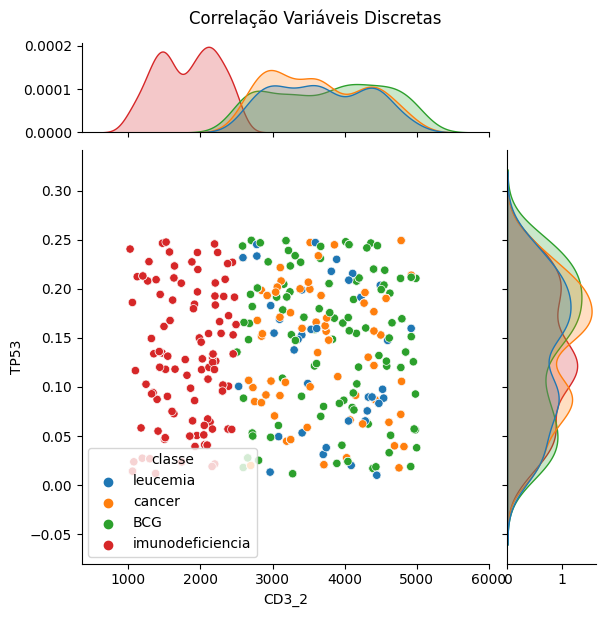

----------


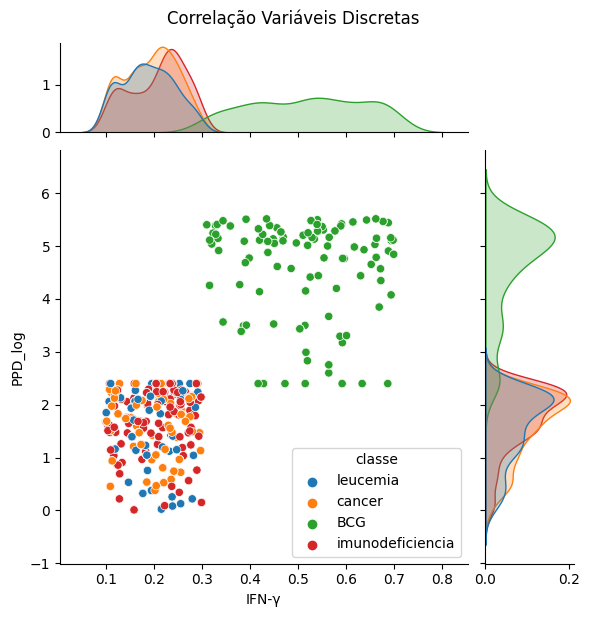

----------


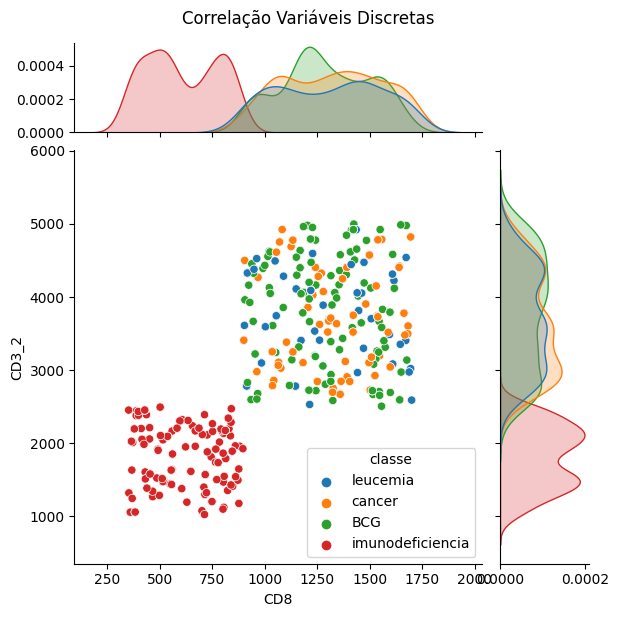

----------


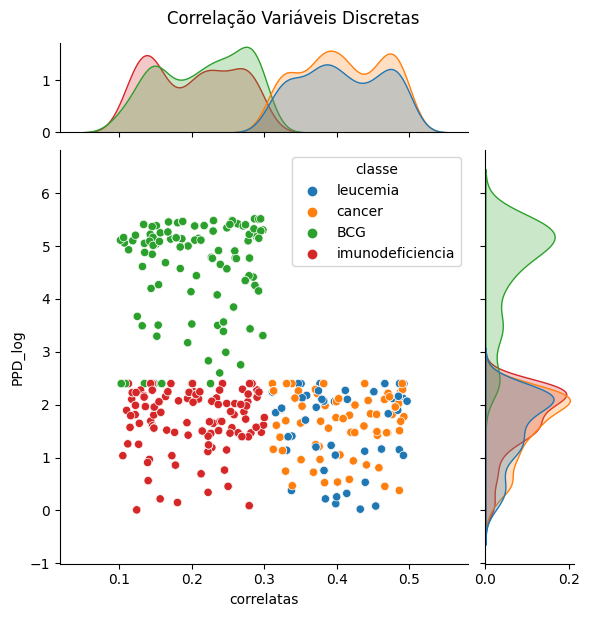

In [413]:
for i in enumerate(eixos_graficos):
    print('-'*10)
    c1 = i[1][0]
    c2 = i[1][1]
    p = sns.jointplot(
        x=num_columns[c1],
        y=num_columns[c2],
        hue='classe',
        height=6,
        ratio=4,
        marginal_ticks=True,
        data=df_projeto,
    )
    p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
    p.set_axis_labels(
        xlabel=num_columns[c1],
        ylabel=num_columns[c2]
    )
    plt.show()

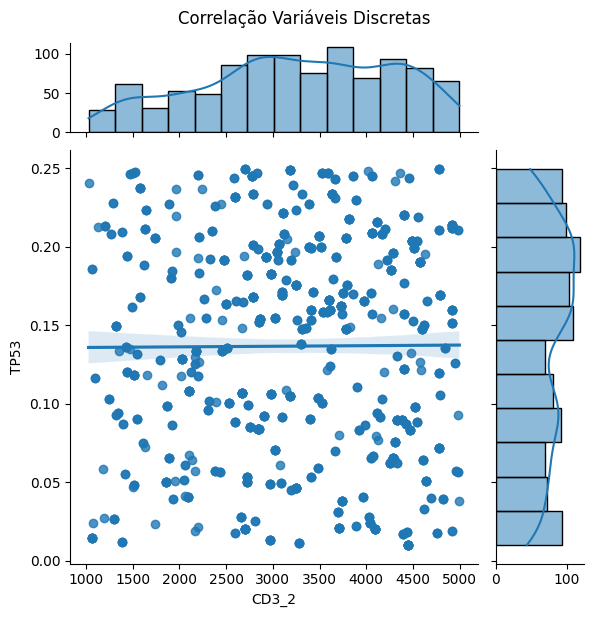

In [415]:
c1 = eixos_graficos[0][0]
c2 = eixos_graficos[0][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()

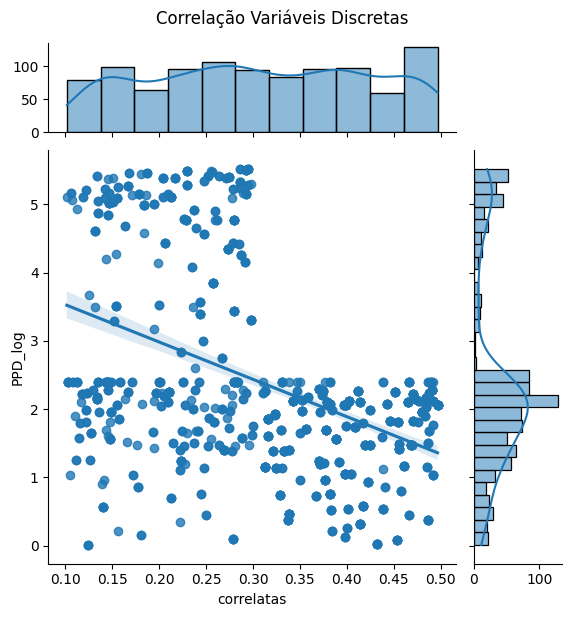

In [416]:
c1 = eixos_graficos[-1][0]
c2 = eixos_graficos[-1][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()

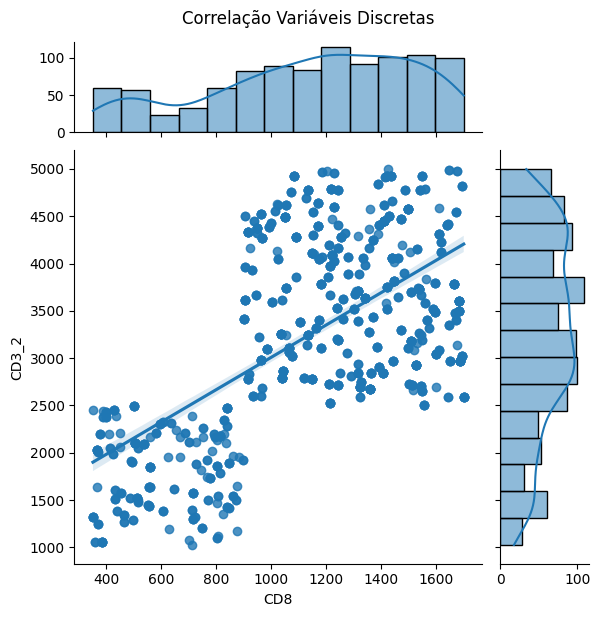

In [417]:
c1 = eixos_graficos[-2][0]
c2 = eixos_graficos[-2][1]
p = sns.jointplot(
    x=num_columns[c1],
    y=num_columns[c2],
    kind='reg',
    height=6,
    ratio=4,
    marginal_ticks=True,
    data=df_projeto,
)
p.fig.suptitle(f"Correlação Variáveis Discretas", y=1.02)
p.set_axis_labels(
    xlabel=num_columns[c1],
    ylabel=num_columns[c2]
)
plt.show()